In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark.sql.functions as f
import statsmodels.api as sm
from gentropy.common.session import Session

Loading BokehJS ...

/Users/dc16/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "10g"})

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/29 11:49:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
release_path = "../../../data/25.06/output/"
output_path = "../../../data/intermediate_files/"

In [4]:
target = session.spark.read.parquet(f"{release_path}/target")
l2g = session.spark.read.parquet(f"{output_path}/list_of_prioritised_genes_per_CS.parquet")
cred_sets = session.spark.read.parquet(
    f"{output_path}/qualifying_credible_sets",
)
studies = (
    session.spark.read.parquet(f"{output_path}/gwas_w_therapeutic_areas")
    .filter(~f.col("measurement"))
    .filter(f.col("binaryLessCases"))
    .drop("geneId")
)
tissue_specificity = session.spark.read.parquet(f"{release_path}/target_prioritisation").select(
    "targetId", "tissueSpecificity", "tissueDistribution"
)
qualified_studies = session.spark.read.parquet(f"{output_path}/qualifying_gwas_studies").select("studyId")

In [5]:
studies.count()

17788

In [6]:
studies.join(qualified_studies, "studyId", "semi").count()

15730

In [7]:
l2g_signif = (
    l2g.join(
        cred_sets.select(
            "studyLocusId",
            "studyId",
            "variantId",
        ),
        "studyLocusId",
        "inner",
    )
    .join(studies, "studyId", "inner")
    .join(qualified_studies, "studyId", "semi")
    .withColumn(
        "publicationDate",
        f.when(f.col("studyId").startswith("FINNGEN"), "2023-01-18").otherwise(f.col("publicationDate")),
    )
    .withColumn(
        "effectiveSampleSize",
        (f.lit(4.0) * f.col("nCases") * f.col("nControls")) / (f.col("nCases") + f.col("nControls")),
    )
)

In [8]:
l2g_signif.count()

70400

In [9]:
(
    l2g_signif.agg(
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias("uniqueDiseases"),
        f.size(f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))).alias("uniqueTherapeuticAreas"),
        f.sum("cancerOrBenignTumor").alias("cancerOrBenignTumor"),
        f.sum("infectiousDisease").alias("infectiousDisease"),
        f.sum("pregnancyOrPerinatalDisease").alias("pregnancyOrPerinatalDisease"),
        f.sum("disorderOfVisualSystem").alias("disorderOfVisualSystem"),
        f.sum("cardiovascularDisease").alias("cardiovascularDisease"),
        f.sum("pancreasDisease").alias("pancreasDisease"),
        f.sum("gastrointestinalDisease").alias("gastrointestinalDisease"),
        f.sum("reproductiveSystemOrBreastDisease").alias("reproductiveSystemOrBreastDisease"),
        f.sum("integumentarySystemDisease").alias("integumentarySystemDisease"),
        f.sum("endocrineSystemDisease").alias("endocrineSystemDisease"),
        f.sum("respiratoryOrThoracicDisease").alias("respiratoryOrThoracicDisease"),
        f.sum("urinarySystemDisease").alias("urinarySystemDisease"),
        f.sum("musculoskeletalOrConnectiveTissueDisease").alias("musculoskeletalOrConnectiveTissueDisease"),
        f.sum("disorderOfEar").alias("disorderOfEar"),
        f.sum("immuneSystemDisease").alias("immuneSystemDisease"),
        f.sum("hematologicDisease").alias("hematologicDisease"),
        f.sum("nervousSystemDisease").alias("nervousSystemDisease"),
        f.sum("psychiatricDisorder").alias("psychiatricDisorder"),
        f.sum("nutritionalOrMetabolicDisease").alias("nutritionalOrMetabolicDisease"),
        f.sum("geneticFamilialOrCongenitalDisease").alias("geneticFamilialOrCongenitalDisease"),
        f.sum("injuryPoisoningOrOtherComplication").alias("injuryPoisoningOrOtherComplication"),
        f.sum("signOrSymptom").alias("signOrSymptom"),
        f.sum("other").alias("other"),
    ).show(vertical=True)
)

26/01/29 11:49:13 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


-RECORD 0-----------------------------------------
 uniqueDiseases                           | 1394  
 uniqueTherapeuticAreas                   | 23    
 cancerOrBenignTumor                      | 10916 
 infectiousDisease                        | 1045  
 pregnancyOrPerinatalDisease              | 230   
 disorderOfVisualSystem                   | 3865  
 cardiovascularDisease                    | 10447 
 pancreasDisease                          | 6271  
 gastrointestinalDisease                  | 2117  
 reproductiveSystemOrBreastDisease        | 760   
 integumentarySystemDisease               | 1323  
 endocrineSystemDisease                   | 1681  
 respiratoryOrThoracicDisease             | 3962  
 urinarySystemDisease                     | 1034  
 musculoskeletalOrConnectiveTissueDisease | 5289  
 disorderOfEar                            | 134   
 immuneSystemDisease                      | 8020  
 hematologicDisease                       | 318   
 nervousSystemDisease          

In [10]:
genes_pleiotropy = (
    l2g_signif.groupBy("geneId")
    .agg(
        f.size(f.array_distinct(f.collect_list("variantId"))).alias("uniqueVariants"),
        f.size(f.array_distinct(f.flatten(f.collect_list("diseaseIds")))).alias("uniqueDiseases"),
        f.size(f.array_distinct(f.flatten(f.collect_list("mappedTherapeuticAreas")))).alias("uniqueTherapeuticAreas"),
        f.max("eQTL_coloc").alias("maxEQTLColoc"),
        f.max("pQTL_coloc").alias("maxPQTLColoc"),
        f.max("VEP").alias("maxVEP"),
        f.max("distanceTSS").alias("maxDistanceTSS"),
        f.min(f.col("effectiveSampleSize")).alias("minEffectiveSampleSize"),
        f.max(f.col("effectiveSampleSize")).alias("maxEffectiveSampleSize"),
        f.min("publicationDate").alias("earliestPublicationDate"),
        f.sum("cancerOrBenignTumor").alias("cancerOrBenignTumor"),
        f.sum("infectiousDisease").alias("infectiousDisease"),
        f.sum("pregnancyOrPerinatalDisease").alias("pregnancyOrPerinatalDisease"),
        f.sum("disorderOfVisualSystem").alias("disorderOfVisualSystem"),
        f.sum("cardiovascularDisease").alias("cardiovascularDisease"),
        f.sum("pancreasDisease").alias("pancreasDisease"),
        f.sum("gastrointestinalDisease").alias("gastrointestinalDisease"),
        f.sum("reproductiveSystemOrBreastDisease").alias("reproductiveSystemOrBreastDisease"),
        f.sum("integumentarySystemDisease").alias("integumentarySystemDisease"),
        f.sum("endocrineSystemDisease").alias("endocrineSystemDisease"),
        f.sum("respiratoryOrThoracicDisease").alias("respiratoryOrThoracicDisease"),
        f.sum("urinarySystemDisease").alias("urinarySystemDisease"),
        f.sum("musculoskeletalOrConnectiveTissueDisease").alias("musculoskeletalOrConnectiveTissueDisease"),
        f.sum("disorderOfEar").alias("disorderOfEar"),
        f.sum("immuneSystemDisease").alias("immuneSystemDisease"),
        f.sum("hematologicDisease").alias("hematologicDisease"),
        f.sum("nervousSystemDisease").alias("nervousSystemDisease"),
        f.sum("psychiatricDisorder").alias("psychiatricDisorder"),
        f.sum("nutritionalOrMetabolicDisease").alias("nutritionalOrMetabolicDisease"),
        f.sum("geneticFamilialOrCongenitalDisease").alias("geneticFamilialOrCongenitalDisease"),
        f.sum("injuryPoisoningOrOtherComplication").alias("injuryPoisoningOrOtherComplication"),
        f.sum("signOrSymptom").alias("signOrSymptom"),
        f.sum("other").alias("other"),
    )
    .withColumn(
        "totalStudies",
        f.col("cancerOrBenignTumor")
        + f.col("infectiousDisease")
        + f.col("pregnancyOrPerinatalDisease")
        + f.col("disorderOfVisualSystem")
        + f.col("cardiovascularDisease")
        + f.col("pancreasDisease")
        + f.col("gastrointestinalDisease")
        + f.col("reproductiveSystemOrBreastDisease")
        + f.col("integumentarySystemDisease")
        + f.col("endocrineSystemDisease")
        + f.col("respiratoryOrThoracicDisease")
        + f.col("urinarySystemDisease")
        + f.col("musculoskeletalOrConnectiveTissueDisease")
        + f.col("disorderOfEar")
        + f.col("immuneSystemDisease")
        + f.col("hematologicDisease")
        + f.col("nervousSystemDisease")
        + f.col("psychiatricDisorder")
        + f.col("nutritionalOrMetabolicDisease")
        + f.col("geneticFamilialOrCongenitalDisease")
        + f.col("injuryPoisoningOrOtherComplication")
        + f.col("signOrSymptom")
        + f.col("other"),
    )
    .join(
        target.withColumns(
            {
                "lofConstraint": f.filter("constraint", lambda x: x.constraintType == "lof")[0]["oeUpper"],
                "misConstraint": f.filter("constraint", lambda x: x.constraintType == "mis")[0]["score"],
                "synConstraint": f.filter("constraint", lambda x: x.constraintType == "syn")[0]["score"],
                "geneLength": f.col("genomicLocation.end") - f.col("genomicLocation.start"),
            }
        ).select(
            "id",
            "approvedSymbol",
            "lofConstraint",
            "misConstraint",
            "synConstraint",
            f.size("pathways").alias("pathwayCount"),
            "geneLength",
        ),
        target["id"] == f.col("geneId"),
        "inner",
    )
    .withColumn(
        "pathwayCount",
        f.when(f.col("pathwayCount") == -1, f.lit(0)).otherwise(f.col("pathwayCount")),
    )
    .withColumn("lofConstraint", 1 - f.col("lofConstraint"))
    .drop(
        "id",
    )
    .join(tissue_specificity, f.col("targetId") == f.col("geneId"), "inner")
    .drop("targetId")
    .sort(f.desc("uniqueTherapeuticAreas"))
)

In [11]:
molqtls = (
    session.spark.read.parquet("/users/dc16/data/releases/25.06/credible_set")
    .filter(f.col("studyType") != "gwas")
    .join(
        session.spark.read.parquet("/users/dc16/data/releases/25.06/study").select("studyId", "geneId", "biosampleId"),
        "studyId",
        "inner",
    )
    .persist()
)
genes_tissues = (
    molqtls.groupBy("geneId")
    .agg(f.count_distinct("biosampleId").alias("nTissues"))
    .sort("nTissues", ascending=False)
    .persist()
)

In [12]:
genes_pleiotropy = genes_pleiotropy.join(genes_tissues, "geneId", "left").withColumn(
    "nTissues", f.when(f.col("nTissues").isNull(), 0).otherwise(f.col("nTissues"))
)

In [13]:
genes_pleiotropy.select("geneId").distinct().count()

8285

In [14]:
genes_pleiotropy.write.parquet(
    f"{output_path}/genes_pleiotropy",
    mode="overwrite",
)

26/01/29 11:49:57 WARN MemoryStore: Not enough space to cache rdd_135_21 in memory! (computed 3.9 MiB so far)
26/01/29 11:49:57 WARN MemoryStore: Not enough space to cache rdd_135_19 in memory! (computed 29.7 MiB so far)
26/01/29 11:49:57 WARN MemoryStore: Not enough space to cache rdd_135_20 in memory! (computed 4.1 MiB so far)
26/01/29 11:49:57 WARN MemoryStore: Not enough space to cache rdd_135_22 in memory! (computed 30.7 MiB so far)
26/01/29 11:49:58 WARN MemoryStore: Not enough space to cache rdd_135_28 in memory! (computed 30.5 MiB so far)
26/01/29 11:49:58 WARN MemoryStore: Not enough space to cache rdd_135_35 in memory! (computed 30.8 MiB so far)
26/01/29 11:50:01 WARN MemoryStore: Not enough space to cache rdd_135_91 in memory! (computed 3.9 MiB so far)
26/01/29 11:50:02 WARN MemoryStore: Not enough space to cache rdd_135_111 in memory! (computed 29.1 MiB so far)


In [15]:
genes_pleiotropy.agg(
    f.min("uniqueTherapeuticAreas"),
    f.mean("uniqueTherapeuticAreas"),
    f.max("uniqueTherapeuticAreas"),
    f.variance("uniqueTherapeuticAreas"),
).show()

+---------------------------+---------------------------+---------------------------+--------------------------------+
|min(uniqueTherapeuticAreas)|avg(uniqueTherapeuticAreas)|max(uniqueTherapeuticAreas)|var_samp(uniqueTherapeuticAreas)|
+---------------------------+---------------------------+---------------------------+--------------------------------+
|                          1|         2.4258298129149063|                         20|               3.899767312896695|
+---------------------------+---------------------------+---------------------------+--------------------------------+



In [16]:
print(
    "Number of protein-coding genes with constraint score assigned to a therapeutic area:",
    genes_pleiotropy.count(),
)
genes_pleiotropy.agg(f.mean("lofConstraint"), f.mean("misConstraint"), f.mean("synConstraint")).show()

Number of protein-coding genes with constraint score assigned to a therapeutic area: 8285


+-------------------+------------------+-------------------+
| avg(lofConstraint)|avg(misConstraint)| avg(synConstraint)|
+-------------------+------------------+-------------------+
|0.18717963349310174| 0.932347227861505|-0.2634449730044874|
+-------------------+------------------+-------------------+



In [17]:
genes_not_assigned = (
    target.filter(~f.col("id").isin([row["geneId"] for row in genes_pleiotropy.select("geneId").collect()]))
    .filter(f.col("biotype") == "protein_coding")
    .withColumns(
        {
            "lofConstraint": f.filter("constraint", lambda x: x.constraintType == "lof")[0]["oeUpper"],
            "misConstraint": f.filter("constraint", lambda x: x.constraintType == "mis")[0]["score"],
            "synConstraint": f.filter("constraint", lambda x: x.constraintType == "syn")[0]["score"],
        }
    )
    .select(
        "id",
        "approvedSymbol",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
    )
    .withColumn("lofConstraint", 1 - f.col("lofConstraint"))
)
print(
    "Number of protein-coding genes with a loss-of-function constraint score not assigned to a therapeutic area:",
    genes_not_assigned.count(),
)
genes_not_assigned.agg(f.mean("lofConstraint"), f.mean("misConstraint"), f.mean("synConstraint")).show()

Number of protein-coding genes with a loss-of-function constraint score not assigned to a therapeutic area: 11845
+--------------------+------------------+--------------------+
|  avg(lofConstraint)|avg(misConstraint)|  avg(synConstraint)|
+--------------------+------------------+--------------------+
|-0.00942190688232...|0.6865409455947424|-0.17374367305498684|
+--------------------+------------------+--------------------+



In [18]:
genes_pd = genes_pleiotropy.toPandas()

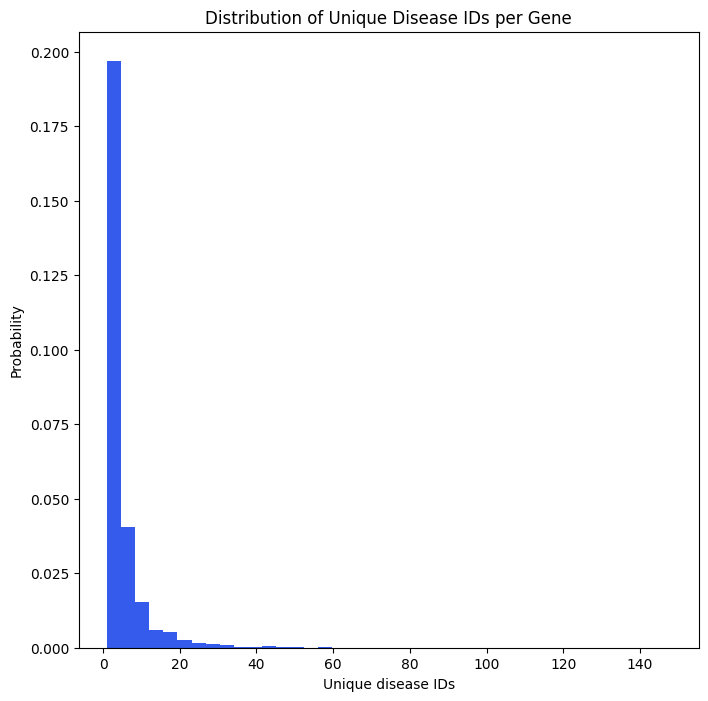

In [19]:
plt.figure(figsize=(8, 8))
plt.hist(
    genes_pd["uniqueDiseases"],
    density=True,
    color="#345BEB",
    bins=len(
        genes_pd[genes_pd["uniqueDiseases"] <= 40]["uniqueDiseases"].unique()
    ),  # Adjust bins for better visualization
)
plt.xlabel("Unique disease IDs")
plt.ylabel("Probability")
plt.title("Distribution of Unique Disease IDs per Gene")
plt.show()

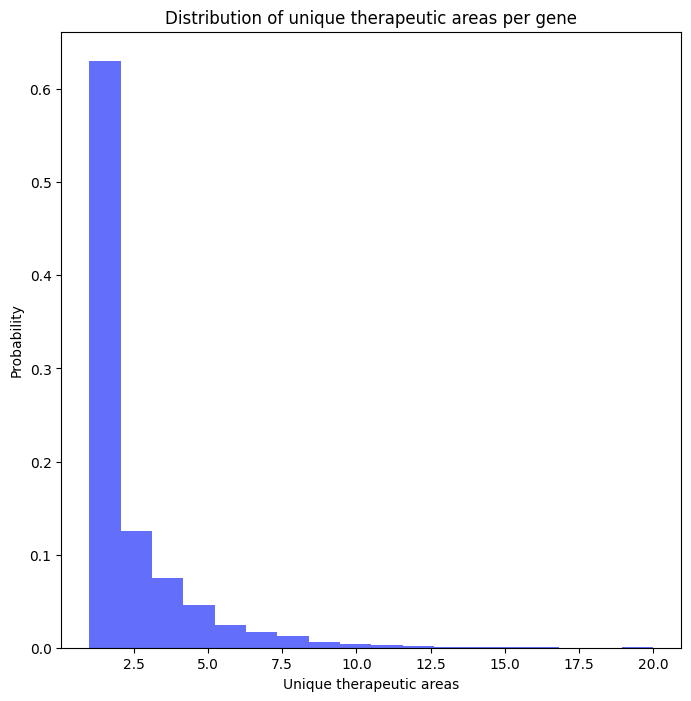

In [20]:
plt.figure(figsize=(8, 8))
plt.hist(
    genes_pd["uniqueTherapeuticAreas"],
    density=True,
    color="#636EFA",
    bins=len(genes_pd["uniqueTherapeuticAreas"].unique()),
)
plt.xlabel("Unique therapeutic areas")
plt.ylabel("Probability")
plt.title("Distribution of unique therapeutic areas per gene")
plt.show()

In [21]:
print("Number with more than one:", len(genes_pd[genes_pd["uniqueTherapeuticAreas"] > 1]))
print(
    "Percentage with more than 1:",
    len(genes_pd[genes_pd["uniqueTherapeuticAreas"] > 1]) / len(genes_pd),
)
print("Mean:", genes_pd["uniqueTherapeuticAreas"].mean())
print("Median:", genes_pd["uniqueTherapeuticAreas"].median())
print("Max:", genes_pd["uniqueTherapeuticAreas"].max())
print("Standard Deviation:", genes_pd["uniqueTherapeuticAreas"].std())

Number with more than one: 4662
Percentage with more than 1: 0.5627036813518407
Mean: 2.4258298129149063
Median: 2.0
Max: 20
Standard Deviation: 1.9747828520869564


In [22]:
print("Number with more than one:", len(genes_pd[genes_pd["uniqueDiseases"] > 1]))
print(
    "Percentage with more than 1:",
    len(genes_pd[genes_pd["uniqueDiseases"] > 1]) / len(genes_pd),
)
print("Mean:", genes_pd["uniqueDiseases"].mean())
print("Median:", genes_pd["uniqueDiseases"].median())
print("Max:", genes_pd["uniqueDiseases"].max())
print("Standard Deviation:", genes_pd["uniqueDiseases"].std())

Number with more than one: 5314
Percentage with more than 1: 0.6414001207000604
Mean: 4.448762824381412
Median: 2.0
Max: 148
Standard Deviation: 6.635319325896013


In [23]:
print("Min:", genes_pd["lofConstraint"].min())
print("Mean:", genes_pd["lofConstraint"].mean())
print("Median:", genes_pd["lofConstraint"].median())
print("Max:", genes_pd["lofConstraint"].max())

Min: -0.995
Mean: 0.18717964
Median: 0.26099998
Max: 0.97


In [24]:
print(genes_pd["uniqueTherapeuticAreas"].corr(genes_pd["uniqueDiseases"]))

0.836421508093421


# Unique Therapeutic Areas


Univariate regression results:
                  covariate  coefficient  std_error        p_value
0              maxEQTLColoc     0.195654   0.008814  3.674912e-109
1              maxPQTLColoc     0.069577   0.007882   1.073814e-18
2                    maxVEP     0.125891   0.008008   1.078370e-55
3    maxEffectiveSampleSize     0.406300   0.009379   0.000000e+00
4     yearsSincePublication     0.348926   0.006038   0.000000e+00
5             lofConstraint     0.125361   0.009121   5.525970e-43
6             misConstraint     0.046203   0.009027   3.078992e-07
7                geneLength     0.104380   0.006568   7.228439e-57
8              pathwayCount     0.035598   0.007173   6.956501e-07
9                  nTissues    -0.005270   0.008968   5.567453e-01
10  tissueSpecificityBinary    -0.034730   0.009271   1.796634e-04
Estimated Dispersion (Scale): 0.6931481481120242
Multiple regression results:
                  covariate  coefficient  std_error       p_value
0              maxEQT

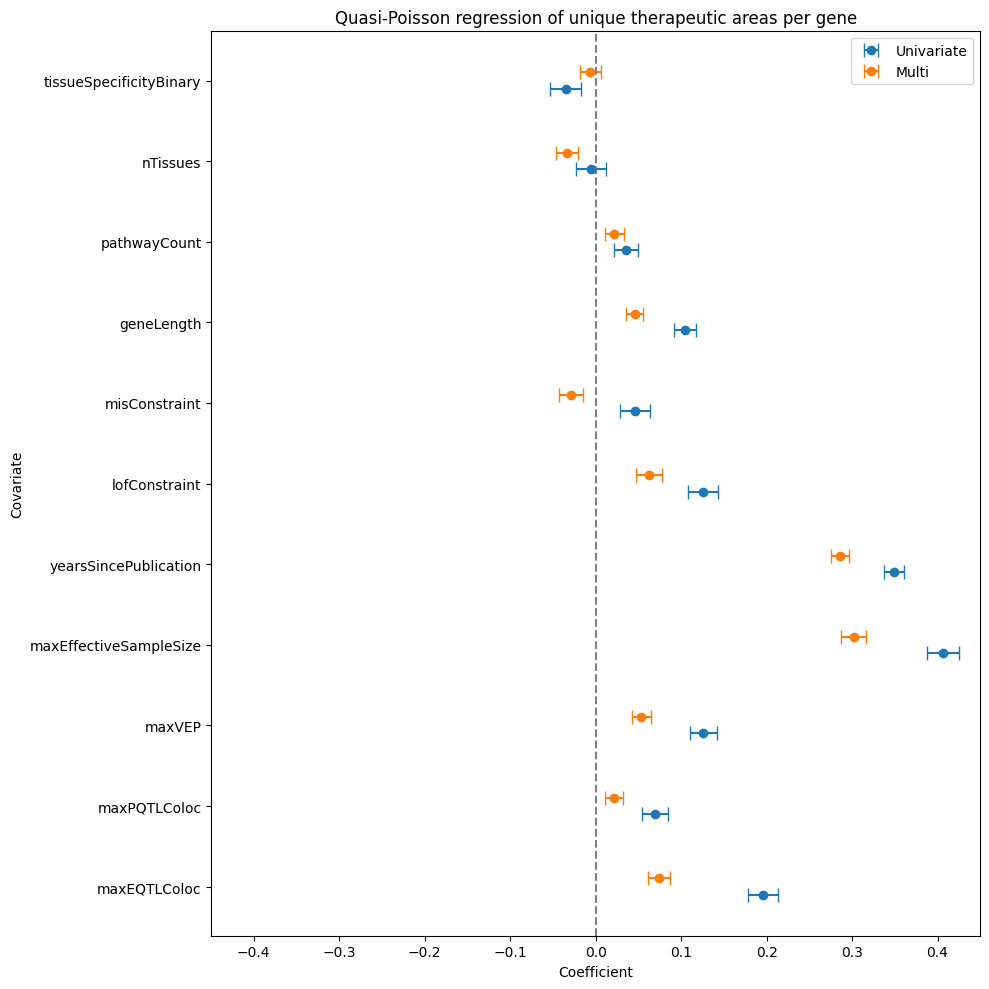

In [25]:
df = genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "uniqueVariants",
        "maxEQTLColoc",
        "maxPQTLColoc",
        "maxVEP",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "lofConstraint",
        "misConstraint",
        "synConstraint",
        "geneLength",
        "pathwayCount",
        "tissueSpecificity",
        "tissueDistribution",
        "nTissues",
    ]
].copy()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["synConstraint"] = df["synConstraint"].fillna(df["synConstraint"].mean())
df["tissueSpecificity"] = df["tissueSpecificity"].fillna(df["tissueSpecificity"].mean())
df["tissueDistribution"] = df["tissueDistribution"].fillna(df["tissueDistribution"].mean())
df["tissueSpecificityBinary"] = (df["tissueSpecificity"] > 0.75).astype(int)
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year

# Standardize covariates
for col in [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    "synConstraint",
    "geneLength",
    "pathwayCount",
    "tissueSpecificity",
    "tissueSpecificityBinary",
    "tissueDistribution",
    "nTissues",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()


covariates_univariate = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    # "synConstraint",
    "geneLength",
    "pathwayCount",
    # "tissueSpecificity",
    # "tissueDistribution",
    "nTissues",
    "tissueSpecificityBinary",
]
covariates_multi = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "lofConstraint",
    "misConstraint",
    # "synConstraint",
    "geneLength",
    "pathwayCount",
    "nTissues",
    "tissueSpecificityBinary",
    # "tissueSpecificity",
    # "tissueDistribution",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueTherapeuticAreas"]
    # scale="X2" uses Pearson chi2 to estimate dispersion (Quasi-Poisson)
    model_uni = sm.GLM(y_uni, x_uni, family=sm.families.Poisson()).fit(scale="X2")
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueTherapeuticAreas"]
# scale="X2" uses Pearson chi2 to estimate dispersion (Quasi-Poisson)
model_multi = sm.GLM(y_multi, x_multi, family=sm.families.Poisson()).fit(scale="X2")

print(f"Estimated Dispersion (Scale): {model_multi.scale}")

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots(figsize=(10, 10))

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=5,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Multi",
    capsize=5,
)

ax.axvline(x=0, color="gray", linestyle="--")
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=10)
ax.set_xlabel("Coefficient")
ax.set_ylabel("Covariate")
ax.set_title("Quasi-Poisson regression of unique therapeutic areas per gene")
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.tight_layout()
plt.show()

In [ ]:
print(np.corrcoef(model_multi.predict(), y_multi)[0, 1] ** 2)

0.44761664232067355


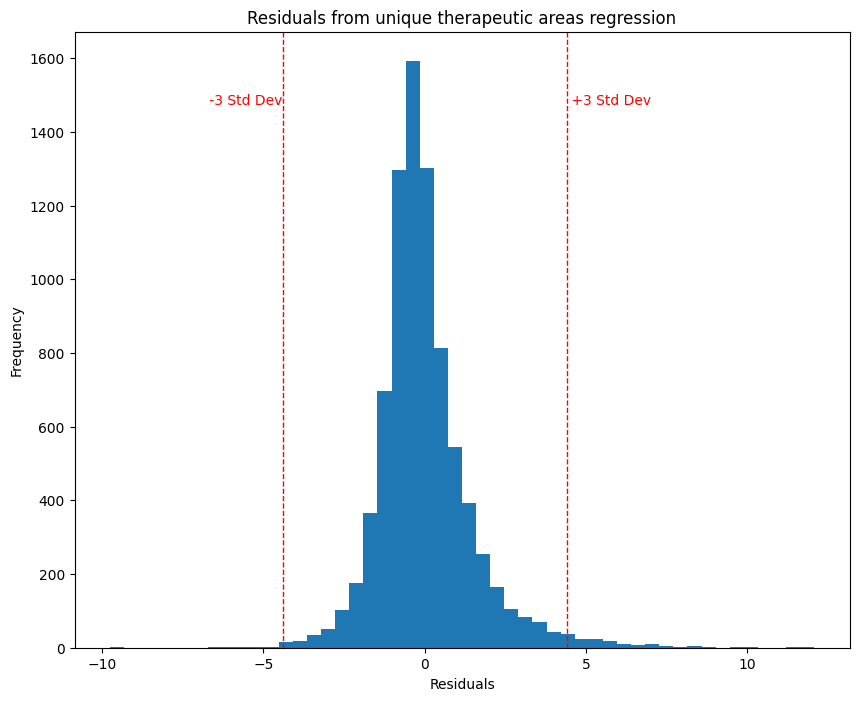

In [28]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique therapeutic areas regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(float(3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)
plt.axvline(float(-3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(
    float(3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " +3 Std Dev",
    color="r",
    verticalalignment="top",
)
plt.text(
    float(-3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()

# Unique diseases full model


Univariate regression results:
                           covariate  coefficient  std_error        p_value
0             maxEQTLColocNormalised     0.626535   0.021753  2.027755e-182
1             maxPQTLColocNormalised     0.517940   0.043179   3.772373e-33
2                   maxVEPNormalised     0.529332   0.026941   6.024630e-86
3   maxEffectiveSampleSizeNormalised     1.823883   0.044449   0.000000e+00
4            lofConstraintNormalised     0.616683   0.044176   2.752334e-44
5            misConstraintNormalised     0.859025   0.198905   1.568998e-05
6               geneLengthNormalised     2.168946   0.159296   3.225901e-42
7             pathwayCountNormalised     3.445320   0.420478   2.530565e-16
8  tissueSpecificityBinaryNormalised    -0.105139   0.032834   1.363946e-03
Multiple regression results:
                           covariate  coefficient  std_error        p_value
0             maxEQTLColocNormalised     0.435405   0.020720   4.956621e-98
1             maxPQTLColocNo

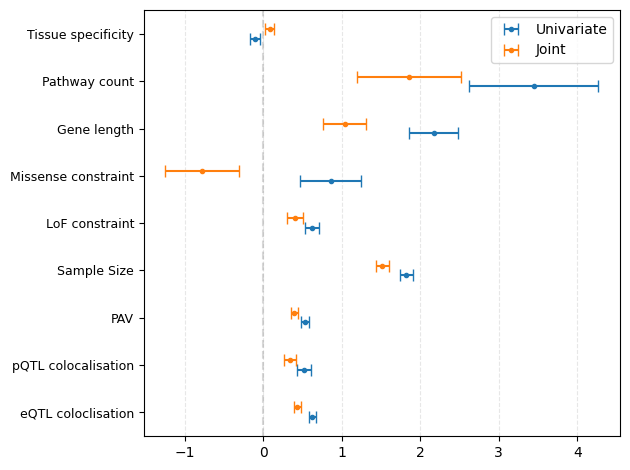

In [32]:
df = genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "maxEQTLColoc",
        "maxPQTLColoc",
        "maxVEP",
        "maxEffectiveSampleSize",
        "lofConstraint",
        "misConstraint",
        "geneLength",
        "pathwayCount",
        "tissueSpecificity",
    ]
].copy()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["tissueSpecificity"] = df["tissueSpecificity"].fillna(df["tissueSpecificity"].mean())
df["tissueSpecificityBinary"] = (df["tissueSpecificity"] > 0.75).astype(int)

# Normalize covariates
for col in [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "maxEffectiveSampleSize",
    "lofConstraint",
    "misConstraint",
    "geneLength",
    "pathwayCount",
    "tissueSpecificityBinary",
]:
    df[f"{col}Normalised"] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())


covariates_univariate = [
    "maxEQTLColocNormalised",
    "maxPQTLColocNormalised",
    "maxVEPNormalised",
    "maxEffectiveSampleSizeNormalised",
    "lofConstraintNormalised",
    "misConstraintNormalised",
    "geneLengthNormalised",
    "pathwayCountNormalised",
    "tissueSpecificityBinaryNormalised",
]
covariates_multi = [
    "maxEQTLColocNormalised",
    "maxPQTLColocNormalised",
    "maxVEPNormalised",
    "maxEffectiveSampleSizeNormalised",
    "lofConstraintNormalised",
    "misConstraintNormalised",
    "geneLengthNormalised",
    "pathwayCountNormalised",
    "tissueSpecificityBinaryNormalised",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    # Increased maxiter to help convergence
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(maxiter=1000, disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
# Increased maxiter to help convergence
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(maxiter=1000, disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)

print("Univariate regression results:")
print(results_df.iloc[:, 0:4])
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
covariate_labels = [
    "eQTL coloclisation",
    "pQTL colocalisation",
    "PAV",
    "Sample Size",
    "LoF constraint",
    "Missense constraint",
    "Gene length",
    "Pathway count",
    "Tissue specificity",
]
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariate_labels, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Re-run the model for 'maxEffectiveSampleSizeNormalised' to extract residuals
covariate_ss = "maxEffectiveSampleSizeNormalised"
x_ss = df[[covariate_ss]].copy()
x_ss = sm.add_constant(x_ss)
y_ss = df["uniqueDiseases"]

# Fit the model
model_ss = sm.NegativeBinomial(y_ss, x_ss).fit(maxiter=1000, disp=False)

# Add residuals to genes_pd
# We use the index from df to ensure alignment, assuming df was derived from genes_pd without dropping rows
genes_pd.loc[df.index, "residuals_maxEffectiveSampleSizeNormalised"] = model_ss.resid_response

print("Added 'residuals_maxEffectiveSampleSizeNormalised' to genes_pd")
print(genes_pd[["geneId", "uniqueDiseases", "residuals_maxEffectiveSampleSizeNormalised"]].head())

Added 'residuals_maxEffectiveSampleSizeNormalised' to genes_pd
            geneId  uniqueDiseases  residuals_maxEffectiveSampleSizeNormalised
0  ENSG00000000460               2                                   -0.854374
1  ENSG00000002822              30                                   16.818610
2  ENSG00000004948               1                                   -8.525758
3  ENSG00000004975               2                                   -1.520344
4  ENSG00000005073               1                                   -2.255029


In [ ]:
print(np.corrcoef(y_ss, model_ss.predict())[0, 1] ** 2)

0.07846449255346574


In [ ]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)

0.15063140303604294


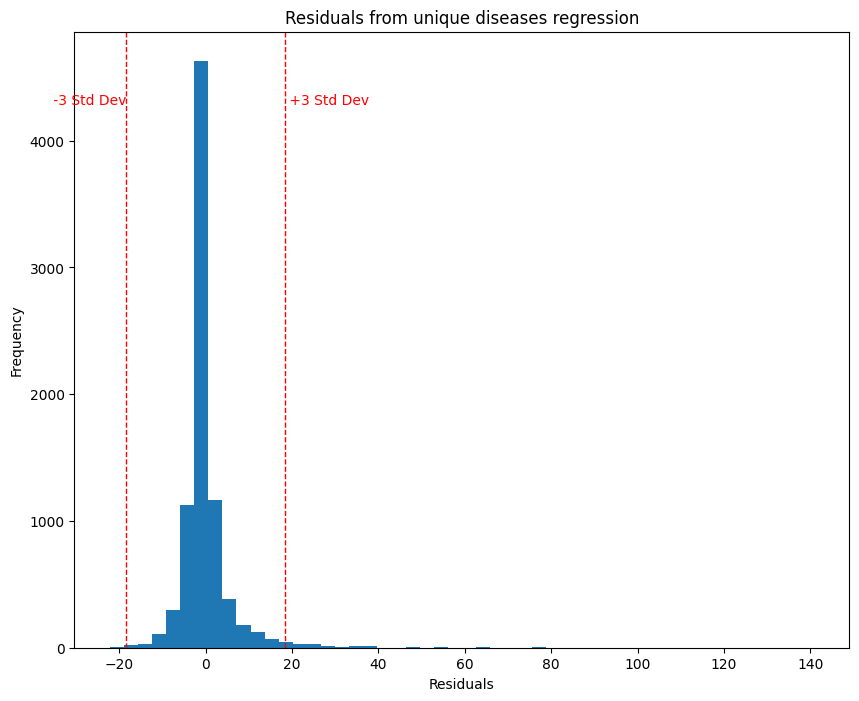

In [37]:
residuals_multi = model_multi.resid_response
std_dev_residuals = np.std(residuals_multi)

plt.figure(figsize=(10, 8))
plt.hist(residuals_multi, bins=50)
plt.title("Residuals from unique diseases regression")
plt.xlabel("Residuals")
plt.ylabel("Frequency")

# Add vertical lines for standard deviations
plt.axvline(float(3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)
plt.axvline(float(-3 * std_dev_residuals), color="r", linestyle="--", linewidth=1)

# Add text annotations for the lines
y_lim = plt.ylim()
plt.text(
    float(3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " +3 Std Dev",
    color="r",
    verticalalignment="top",
)
plt.text(
    float(-3 * std_dev_residuals),
    y_lim[1] * 0.9,
    " -3 Std Dev",
    color="r",
    horizontalalignment="right",
    verticalalignment="top",
)

plt.show()

# Unique diseases biological factors


Univariate regression results:
                 covariate  coefficient  std_error        p_value
0             maxEQTLColoc     0.312666   0.010856  2.027755e-182
1             maxPQTLColoc     0.126859   0.010576   3.772373e-33
2                   maxVEP     0.207662   0.010569   6.024630e-86
3            lofConstraint     0.151514   0.010852   2.656390e-44
4            misConstraint     0.043512   0.010064   1.534795e-05
5             pathwayCount     0.113154   0.013810   2.531605e-16
6  tissueSpecificityBinary    -0.035870   0.011202   1.363946e-03
7                 nTissues    -0.020348   0.011250   7.049771e-02
Multiple regression results:
                 covariate  coefficient  std_error        p_value
0             maxEQTLColoc     0.307120   0.011415  1.951223e-159
1             maxPQTLColoc     0.084691   0.010145   6.916900e-17
2                   maxVEP     0.165290   0.010396   6.429597e-57
3            lofConstraint     0.175732   0.013270   4.957113e-40
4            mis

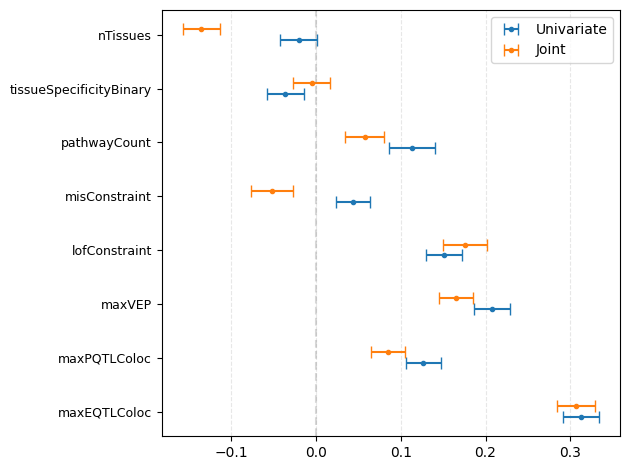

In [38]:
df = genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "maxEQTLColoc",
        "maxPQTLColoc",
        "maxVEP",
        "lofConstraint",
        "misConstraint",
        "pathwayCount",
        "tissueSpecificity",
        "nTissues",
    ]
].copy()
df["lofConstraint"] = df["lofConstraint"].fillna(df["lofConstraint"].mean())
df["misConstraint"] = df["misConstraint"].fillna(df["misConstraint"].mean())
df["tissueSpecificity"] = df["tissueSpecificity"].fillna(df["tissueSpecificity"].mean())
df["tissueSpecificityBinary"] = (df["tissueSpecificity"] > 0.75).astype(int)

# Standardize covariates
for col in [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "lofConstraint",
    "misConstraint",
    "pathwayCount",
    "tissueSpecificityBinary",
    "nTissues",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()

covariates_univariate = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "lofConstraint",
    "misConstraint",
    "pathwayCount",
    "tissueSpecificityBinary",
    "nTissues",
]
covariates_multi = [
    "maxEQTLColoc",
    "maxPQTLColoc",
    "maxVEP",
    "lofConstraint",
    "misConstraint",
    "pathwayCount",
    "tissueSpecificityBinary",
    "nTissues",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
# ax.set_xlabel("Coefficient")
# ax.set_ylabel("Covariate")
# ax.set_title("B")
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)

0.08696976656246425


# Unique diseases statistical factors


Univariate regression results:
                covariate  coefficient  std_error       p_value
0  maxEffectiveSampleSize     0.608629   0.011867  0.000000e+00
1   yearsSincePublication     0.623528   0.008916  0.000000e+00
2              geneLength     0.158854   0.011667  3.245989e-42
Multiple regression results:
                covariate  coefficient  std_error       p_value
0  maxEffectiveSampleSize     0.454005   0.010323  0.000000e+00
1   yearsSincePublication     0.536760   0.007919  0.000000e+00
2              geneLength     0.054879   0.007850  2.729103e-12
Pseudo R-squared: 0.1534830491602739


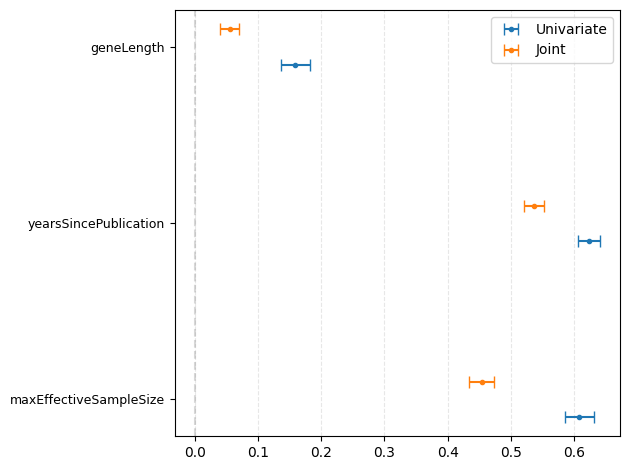

In [ ]:
df = genes_pd[
    [
        "geneId",
        "approvedSymbol",
        "uniqueDiseases",
        "uniqueTherapeuticAreas",
        "maxEffectiveSampleSize",
        "earliestPublicationDate",
        "geneLength",
    ]
].copy()
df["yearsSincePublication"] = 2025 - pd.to_datetime(df["earliestPublicationDate"], errors="coerce").dt.year

# Standardize covariates
for col in [
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "geneLength",
]:
    if col in ["maxEffectiveSampleSize"]:
        # Log transform first, then standardize
        log_transformed = np.log(df[col])
        df[col] = (log_transformed - log_transformed.mean()) / log_transformed.std()
    else:
        df[col] = (df[col] - df[col].mean()) / df[col].std()


covariates_univariate = [
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "geneLength",
]
covariates_multi = [
    "maxEffectiveSampleSize",
    "yearsSincePublication",
    "geneLength",
]

# Univariate results
univariate_results = []
for covariate in covariates_univariate:
    x_uni = df[[covariate]].copy()
    x_uni = sm.add_constant(x_uni)
    y_uni = df["uniqueDiseases"]
    model_uni = sm.NegativeBinomial(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)
print("Univariate regression results:")
print(results_df.iloc[:, 0:4])

# Multivariate model
x_multi = df[covariates_multi].copy()
x_multi = sm.add_constant(x_multi)
y_multi = df["uniqueDiseases"]
model_multi = sm.NegativeBinomial(y_multi, x_multi).fit(disp=False)

# Extract multivariate results for all univariate covariates (fill with NaN if not in model)
multi_results = []
for covariate in covariates_univariate:
    if covariate in covariates_multi:
        coef = model_multi.params[covariate]
        se = model_multi.bse[covariate]
        pvalue = model_multi.pvalues[covariate]
        ci_lower = model_multi.conf_int().loc[covariate, 0]
        ci_upper = model_multi.conf_int().loc[covariate, 1]
    else:
        coef = se = pvalue = ci_lower = ci_upper = np.nan
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)
print("Multiple regression results:")
print(multi_df.iloc[:, 0:4])
print("Pseudo R-squared:", model_multi.prsquared)

# Combine univariate and multivariate results for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Multi"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

y_mapping = {cov: i for i, cov in enumerate(covariates_univariate)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Create combined plot with Matplotlib
fig, ax = plt.subplots()

# Plot univariate results
univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

# Plot multivariate results
multi_data = combined_results[combined_results["model_type"] == "Multi"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
ax.set_yticks([y_mapping[cov] for cov in covariates_univariate])
ax.set_yticklabels(covariates_univariate, fontsize=9)
ax.legend()

max_val = np.nanmax(
    np.abs(
        [
            combined_results["coefficient"],
            combined_results["ci_upper"],
            combined_results["ci_lower"],
        ]
    )
)
# ax.set_xlim(-max_val - 0.025, max_val + 0.025)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print(np.corrcoef(y_multi, model_multi.predict())[0, 1] ** 2)

0.4043473923082393
